<a href="https://colab.research.google.com/github/sundaravelgiriganeshsa/turbofan-rul-prediction/blob/main/project6_turbine_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== DATASET SHAPE =====
(20631, 28)

===== FIRST 10 ROWS =====
   engine_id  cycle     op1     op2    op3  sensor_1  sensor_2  sensor_3  \
0          1      1 -0.0007 -0.0004  100.0    518.67    641.82   1589.70   
1          1      2  0.0019 -0.0003  100.0    518.67    642.15   1591.82   
2          1      3 -0.0043  0.0003  100.0    518.67    642.35   1587.99   
3          1      4  0.0007  0.0000  100.0    518.67    642.35   1582.79   
4          1      5 -0.0019 -0.0002  100.0    518.67    642.37   1582.85   
5          1      6 -0.0043 -0.0001  100.0    518.67    642.10   1584.47   
6          1      7  0.0010  0.0001  100.0    518.67    642.48   1592.32   
7          1      8 -0.0034  0.0003  100.0    518.67    642.56   1582.96   
8          1      9  0.0008  0.0001  100.0    518.67    642.12   1590.98   
9          1     10 -0.0033  0.0001  100.0    518.67    641.71   1591.24   

   sensor_4  sensor_5  ...  sensor_14  sensor_15  sensor_16  sensor_17  \
0   1400.60     14.62  

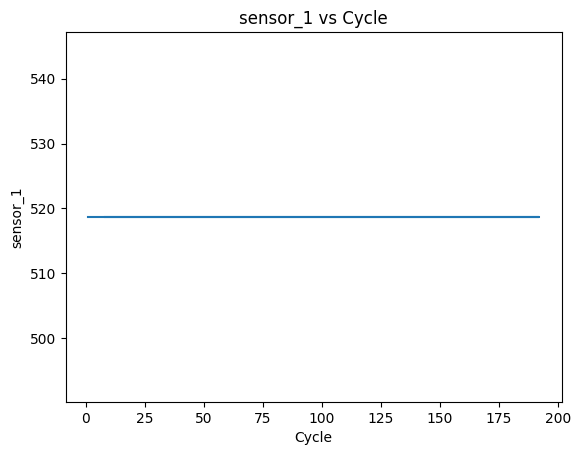

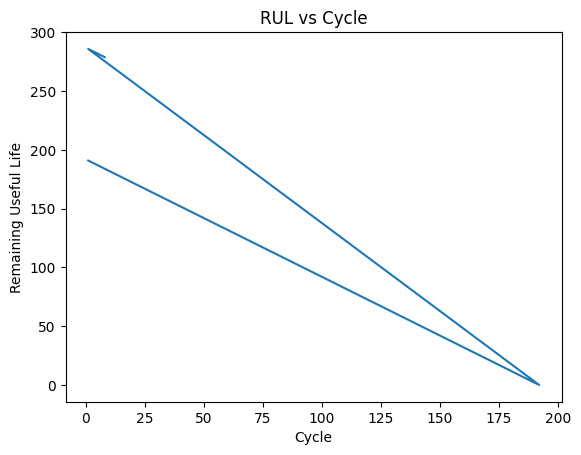

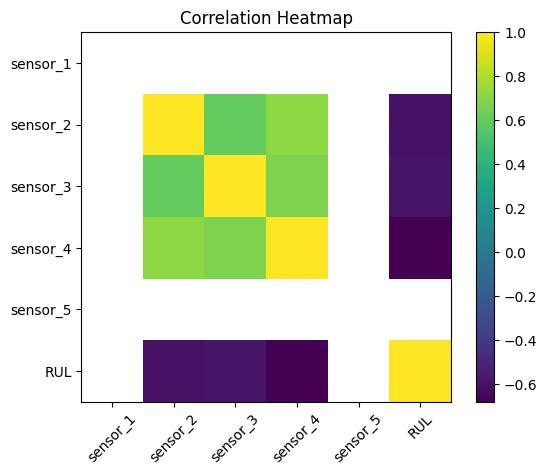

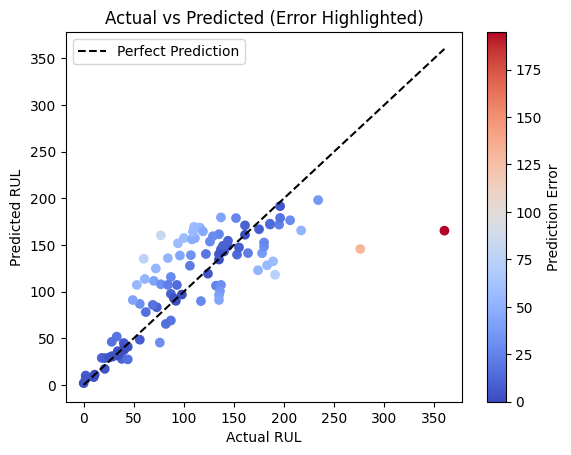

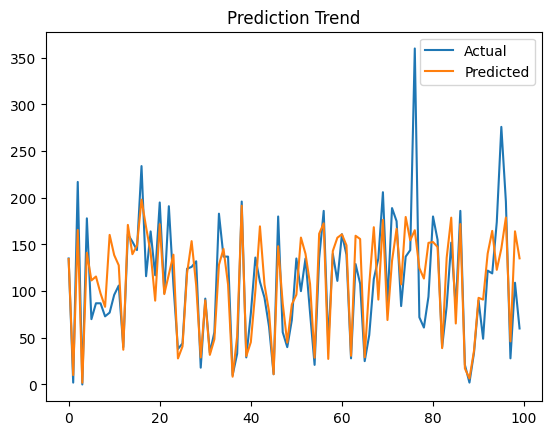

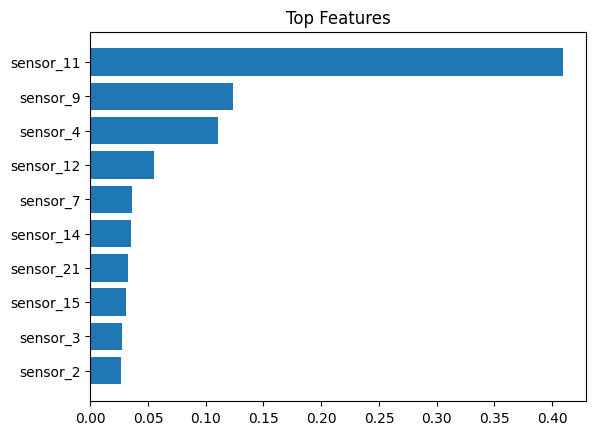

In [ ]:
# -------------------------------
# PRINT DATA
# -------------------------------
print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== FIRST 10 ROWS =====")
print(df.head(10))

print("\n===== LAST 10 ROWS =====")
print(df.tail(10))


# -------------------------------
# ACTUAL vs PREDICTED TABLE
# -------------------------------
result_df = pd.DataFrame({
    "Actual RUL": y_test[:20].values,
    "Predicted RUL": y_pred[:20]
})

print("\n===== ACTUAL vs PREDICTED (Sample) =====")
print(result_df)


# -------------------------------
# Find a useful (non-constant) sensor
# -------------------------------
sensor_cols = [col for col in df.columns if "sensor" in col]
useful_sensor = None

for col in sensor_cols:
    if df[col].std() > 0:
        useful_sensor = col
        break

print("Using sensor for plot:", useful_sensor)


# -------------------------------
# 4. Plot Sensor Data
# -------------------------------
plt.figure()
plt.plot(df['cycle'][:200], df[useful_sensor][:200])
plt.title(f"{useful_sensor} vs Cycle")
plt.xlabel("Cycle")
plt.ylabel(useful_sensor)
plt.show()

print("\n")


# -------------------------------
# 6. Plot RUL
# -------------------------------
plt.figure()
plt.plot(df['cycle'][:200], df['RUL'][:200])
plt.title("RUL vs Cycle")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.show()

print("\n")


# -------------------------------
# 7. Correlation Heatmap
# -------------------------------
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

print("\n")


# -------------------------------
# 12. Graph: Actual vs Predicted
# -------------------------------
plt.figure()

error = abs(y_test[:100] - y_pred[:100])

plt.scatter(y_test[:100], y_pred[:100], c=error, cmap='coolwarm')

plt.plot([0, max(y_test[:100])], [0, max(y_test[:100])], 'k--', label="Perfect Prediction")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted (Error Highlighted)")
plt.colorbar(label="Prediction Error")
plt.legend()

plt.show()

print("\n")


# -------------------------------
# 13. Trend Graph
# -------------------------------
plt.figure()
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Prediction Trend")
plt.show()

print("\n")


# -------------------------------
# 14. Feature Importance
# -------------------------------
plt.figure()
plt.barh(imp_df['Feature'][:10], imp_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()